##### LIBRARIES

In [1]:
import os, random, json, cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor
from sklearn.model_selection import train_test_split
from collections import defaultdict
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

##### DEVICE SET-UP

In [2]:
# Set seeds and device
seed = 2025
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: mps


##### MODULES & MODEL DEFINITION 

In [3]:

#### Data preparation
class NPYTibiaDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        drr_path, mask_path = self.data[idx]
        drr = np.load(drr_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.uint8)

        drr_uint8 = np.uint8(255 * (drr / np.max(drr)))
        drr_clahe = self.clahe.apply(drr_uint8)
        drr_norm = drr_clahe.astype(np.float32) / 255.0

        drr_tensor = torch.tensor(drr_norm, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask > 0, dtype=torch.float32).unsqueeze(0)

        return drr_tensor, mask_tensor

class ToTensorTransform:
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __call__(self, drr, mask):
        drr_uint8 = np.uint8(255 * (drr / np.max(drr)))
        drr_clahe = self.clahe.apply(drr_uint8)
        drr_norm = drr_clahe.astype(np.float32) / 255.0
        drr_tensor = torch.tensor(drr_norm, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask > 0, dtype=torch.float32).unsqueeze(0)
        return drr_tensor, mask_tensor

def split_npy_dataset_by_knee(root_drr, root_mask, val_split=0.2, test_split=0.15, seed=2025):
    knees = defaultdict(list)

    for root, dirs, files in os.walk(root_drr):
        for file in files:
            if file.endswith(".npy") and "drr" in file:
                drr_path = os.path.join(root, file)
                rel_path = os.path.relpath(drr_path, root_drr)
                parts = rel_path.split(os.sep)
                knee_id = f"{parts[0]}_{parts[1]}"  # f_001_left

                mask_path = os.path.join(root_mask, rel_path.replace("drr", "mask"))
                if os.path.exists(mask_path):
                    knees[knee_id].append((drr_path, mask_path))

    base_knees = sorted(set("_".join(k.split("_")[:2]) for k in knees.keys()))
    train_val_bases, test_bases = train_test_split(base_knees, test_size=test_split, random_state=seed)
    train_bases, val_bases = train_test_split(train_val_bases, test_size=val_split / (1 - test_split), random_state=seed)

    train_data, val_data, test_data = [], [], []
    train_ids, val_ids, test_ids = [], [], []

    for knee_id in knees:
        base_id = "_".join(knee_id.split("_")[:2])
        if base_id in train_bases:
            train_data.extend(knees[knee_id])
            train_ids.append(knee_id)
        elif base_id in val_bases:
            val_data.extend(knees[knee_id])
            val_ids.append(knee_id)
        elif base_id in test_bases:
            test_data.extend(knees[knee_id])
            test_ids.append(knee_id)

    print(f"\n🦵 Knees in each set:")
    print(f"Train: {sorted(set(train_ids))}")
    print(f"Val:   {sorted(set(val_ids))}")
    print(f"Test:  {sorted(set(test_ids))}")
    print(f"\n🔀 Split -> Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

    return train_data, val_data, test_data

##### Attention U-Net Model
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, kernel_size=1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, kernel_size=1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, kernel_size=1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class AttentionUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.maxpool = nn.MaxPool2d(2)

        self.down1 = ConvBlock(in_ch, 64)
        self.down2 = ConvBlock(64, 128)
        self.down3 = ConvBlock(128, 256)
        self.down4 = ConvBlock(256, 512)

        self.middle = ConvBlock(512, 1024)

        self.att4 = AttentionBlock(F_g=1024, F_l=512, F_int=512)
        self.up4 = ConvBlock(1024 + 512, 512)

        self.att3 = AttentionBlock(F_g=512, F_l=256, F_int=256)
        self.up3 = ConvBlock(512 + 256, 256)

        self.att2 = AttentionBlock(F_g=256, F_l=128, F_int=128)
        self.up2 = ConvBlock(256 + 128, 128)

        self.att1 = AttentionBlock(F_g=128, F_l=64, F_int=64)
        self.up1 = ConvBlock(128 + 64, 64)

        self.final = nn.Conv2d(64, out_ch, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.maxpool(d1))
        d3 = self.down3(self.maxpool(d2))
        d4 = self.down4(self.maxpool(d3))

        middle = self.middle(self.maxpool(d4))

        g4 = F.interpolate(middle, size=d4.shape[2:], mode='bilinear', align_corners=True)
        a4 = self.att4(g=g4, x=d4)
        u4 = self.up4(torch.cat([g4, a4], dim=1))

        g3 = F.interpolate(u4, size=d3.shape[2:], mode='bilinear', align_corners=True)
        a3 = self.att3(g=g3, x=d3)
        u3 = self.up3(torch.cat([g3, a3], dim=1))

        g2 = F.interpolate(u3, size=d2.shape[2:], mode='bilinear', align_corners=True)
        a2 = self.att2(g=g2, x=d2)
        u2 = self.up2(torch.cat([g2, a2], dim=1))

        g1 = F.interpolate(u2, size=d1.shape[2:], mode='bilinear', align_corners=True)
        a1 = self.att1(g=g1, x=d1)
        u1 = self.up1(torch.cat([g1, a1], dim=1))

        return torch.sigmoid(self.final(u1))


##### Losses + Metrics
class DiceLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice

def iou_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3))
    return (intersection / (union + 1e-6)).mean().item()

def dice_score(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    return (2. * intersection / (preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + 1e-6)).mean().item()

def visualize_prediction(epoch, drr, pred, mask):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(drr.squeeze().cpu(), cmap='gray')
    axs[0].set_title("Input DRR")
    axs[1].imshow(pred.squeeze().cpu().detach(), cmap='gray')
    axs[1].set_title("Prediction")
    axs[2].imshow(mask.squeeze().cpu(), cmap='gray')
    axs[2].set_title("Ground Truth")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Epoch {epoch+1} Prediction")
    plt.tight_layout()
    plt.show()

def show_confusion_matrix(preds, masks):
    all_preds = preds.view(-1).cpu().numpy() > 0.5
    all_masks = masks.view(-1).cpu().numpy()
    cm = confusion_matrix(all_masks, all_preds)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['BG', 'Bone'])
    ax.set_yticklabels(['BG', 'Bone'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="black")

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

def log_metrics(preds, masks, epoch, log_path="epoch_metrics_log.json"):
    preds_flat = preds.view(-1).cpu().numpy() > 0.5
    masks_flat = masks.view(-1).cpu().numpy()
    tn, fp, fn, tp = confusion_matrix(masks_flat, preds_flat).ravel()

    log = {
        "epoch": epoch + 1,
        "true_positive": int(tp),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn)
    }

    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            logs = json.load(f)
    else:
        logs = []

    logs.append(log)
    with open(log_path, 'w') as f:
        json.dump(logs, f, indent=2)

##### Training Loop

def train(model, train_loader, val_loader, epochs=20, lr=1e-4):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = DiceLoss()
    bce = nn.BCELoss()

    patience_counter = 0
    patience = 5
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for drr, mask in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}"):
            drr, mask = drr.to(device), mask.to(device)
            pred = model(drr)
            loss = 0.5 * bce(pred, mask) + 0.5 * criterion(pred, mask)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        print(f"\nEpoch {epoch+1} - Train Loss: {train_loss/len(train_loader):.4f}")

        model.eval()
        with torch.no_grad():
            val_loss = 0
            all_preds, all_targets = [], []
            for drr, mask in val_loader:
                drr, mask = drr.to(device), mask.to(device)
                pred = model(drr)
                loss = 0.5 * bce(pred, mask) + 0.5 * criterion(pred, mask)
                val_loss += loss.item()
                all_preds.append(pred.cpu())
                all_targets.append(mask.cpu())

            all_preds = torch.cat(all_preds, dim=0)
            all_targets = torch.cat(all_targets, dim=0)
            dice = dice_score(all_preds, all_targets)
            iou = iou_score(all_preds, all_targets)
            avg_val_loss = val_loss / len(val_loader)

            print(f"Epoch {epoch+1} - Val Loss: {val_loss/len(val_loader):.4f} - Dice: {dice:.4f} - IoU: {iou:.4f}")
            
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), 'AttentionUNet_V02_AP.pt')
                print(f"💾 Saved best model at epoch {epoch+1}")
                patience_counter = 0

            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print("⛔ Early stopping triggered")
                break
            
            # Visualization for the first batch
            visualize_prediction(epoch, drr[0], pred[0], mask[0])
            show_confusion_matrix(all_preds, all_targets)
            log_metrics(all_preds, all_targets, epoch, log_path="epoch_metrics_log.json")


##### Data Preparation

In [4]:
# Example usage for AP view
drr_dir_ap = "/Users/maximehuppe/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Internship/Dataset/8. Segmentation_data/AP/drr"
mask_dir_ap = "/Users/maximehuppe/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Internship/Dataset/8. Segmentation_data/AP/mask"

train_data, val_data, test_data = split_npy_dataset_by_knee(drr_dir_ap, mask_dir_ap, val_split=0.2, test_split=0.1)

train_set = NPYTibiaDataset(train_data, transform=ToTensorTransform())
val_set = NPYTibiaDataset(val_data, transform=ToTensorTransform())
test_set = NPYTibiaDataset(test_data, transform=ToTensorTransform())

train_loader = DataLoader(train_set, batch_size=4, shuffle=True)
val_loader = DataLoader(val_set, batch_size=4, shuffle=False)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)



🦵 Knees in each set:
Train: ['f_001_left_1', 'f_001_left_10', 'f_001_left_2', 'f_001_left_3', 'f_001_left_4', 'f_001_left_5', 'f_001_left_6', 'f_001_left_7', 'f_001_left_8', 'f_001_left_9', 'f_001_right_1', 'f_001_right_10', 'f_001_right_2', 'f_001_right_3', 'f_001_right_4', 'f_001_right_5', 'f_001_right_6', 'f_001_right_7', 'f_001_right_8', 'f_001_right_9', 'f_003_left_1', 'f_003_left_10', 'f_003_left_2', 'f_003_left_3', 'f_003_left_4', 'f_003_left_5', 'f_003_left_6', 'f_003_left_7', 'f_003_left_8', 'f_003_left_9', 'f_003_right_1', 'f_003_right_10', 'f_003_right_2', 'f_003_right_3', 'f_003_right_4', 'f_003_right_5', 'f_003_right_6', 'f_003_right_7', 'f_003_right_8', 'f_003_right_9', 'f_007_left_1', 'f_007_left_10', 'f_007_left_2', 'f_007_left_3', 'f_007_left_4', 'f_007_left_5', 'f_007_left_6', 'f_007_left_7', 'f_007_left_8', 'f_007_left_9', 'f_007_right_1', 'f_007_right_10', 'f_007_right_2', 'f_007_right_3', 'f_007_right_4', 'f_007_right_5', 'f_007_right_6', 'f_007_right_7', 'f_007_r

##### MODEL TRAINING 

[Train] Epoch 1: 100%|██████████| 208/208 [18:21<00:00,  5.30s/it] 



Epoch 1 - Train Loss: 0.4265
Epoch 1 - Val Loss: 0.3657 - Dice: 0.9596 - IoU: 0.9225
💾 Saved best model at epoch 1


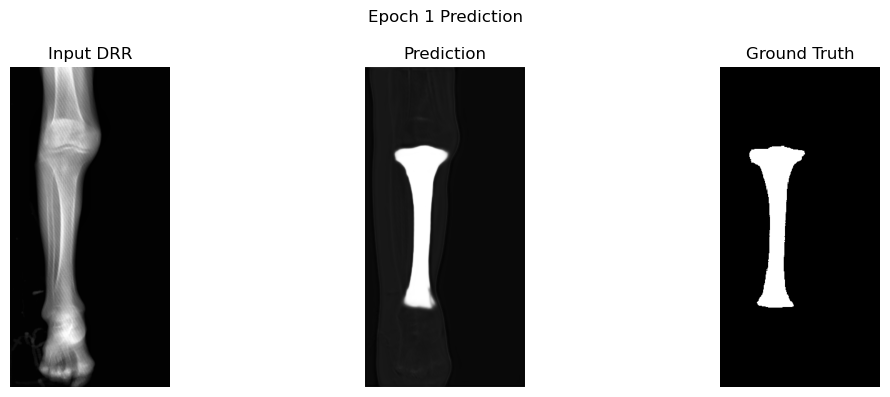

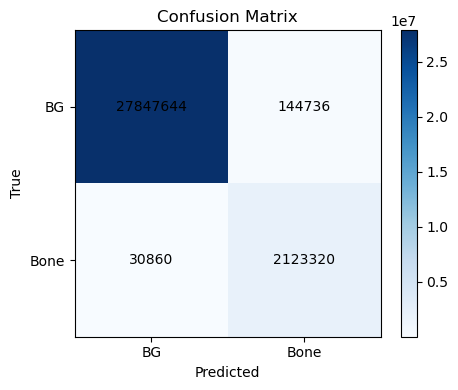

[Train] Epoch 2: 100%|██████████| 208/208 [12:09<00:00,  3.51s/it]



Epoch 2 - Train Loss: 0.3167
Epoch 2 - Val Loss: 0.2807 - Dice: 0.9610 - IoU: 0.9252
💾 Saved best model at epoch 2


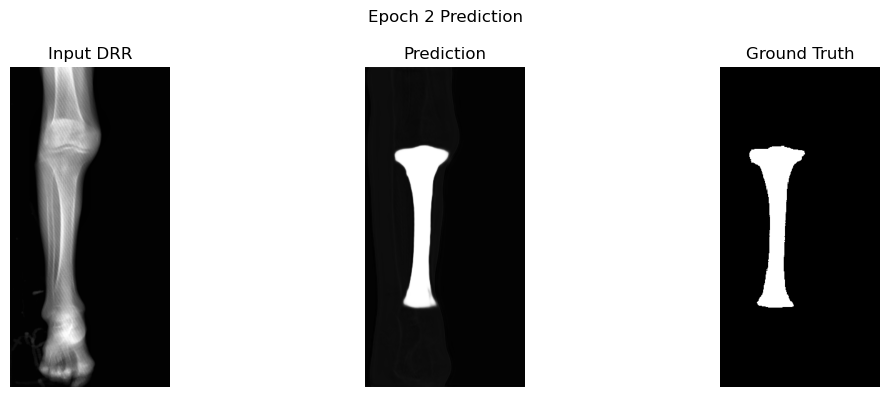

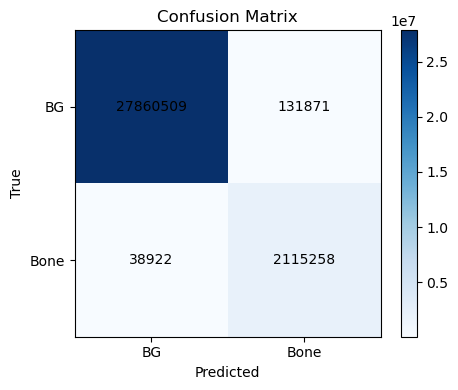

[Train] Epoch 3: 100%|██████████| 208/208 [11:42<00:00,  3.38s/it]



Epoch 3 - Train Loss: 0.2375
Epoch 3 - Val Loss: 0.2150 - Dice: 0.9455 - IoU: 0.8980
💾 Saved best model at epoch 3


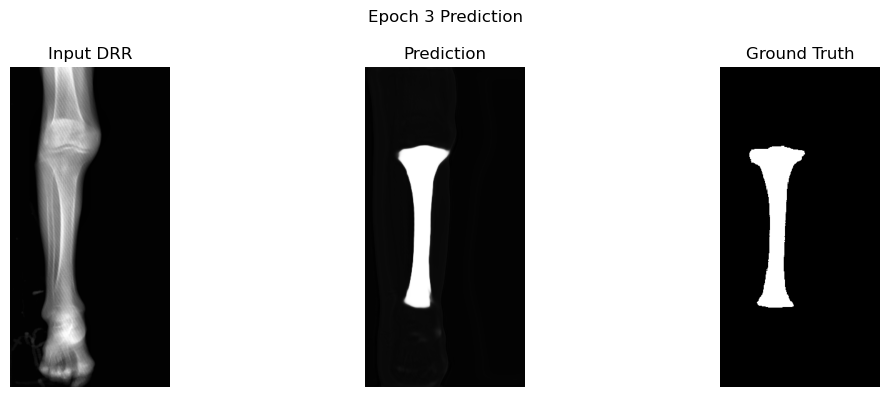

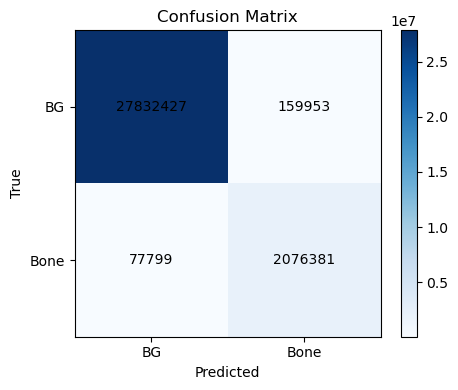

[Train] Epoch 4: 100%|██████████| 208/208 [10:58<00:00,  3.16s/it]



Epoch 4 - Train Loss: 0.1740
Epoch 4 - Val Loss: 0.1635 - Dice: 0.9534 - IoU: 0.9152
💾 Saved best model at epoch 4


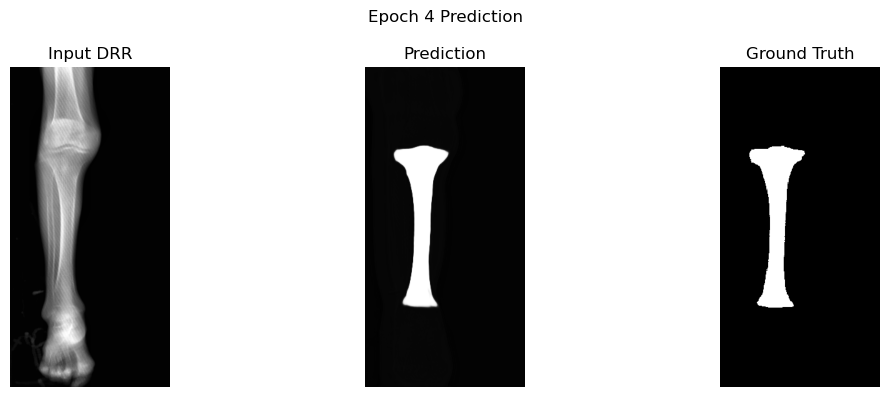

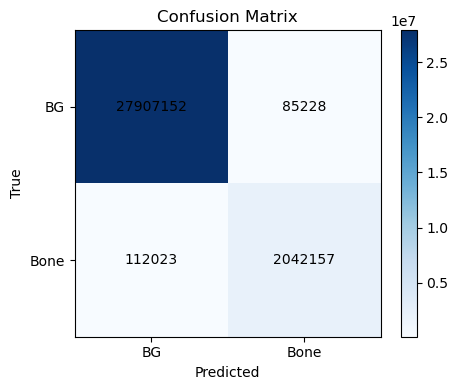

[Train] Epoch 5: 100%|██████████| 208/208 [09:14<00:00,  2.67s/it]



Epoch 5 - Train Loss: 0.1262
Epoch 5 - Val Loss: 0.1099 - Dice: 0.9746 - IoU: 0.9506
💾 Saved best model at epoch 5


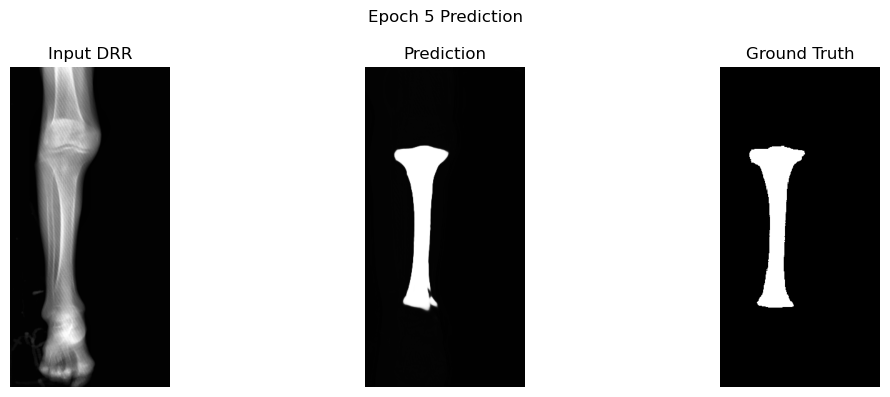

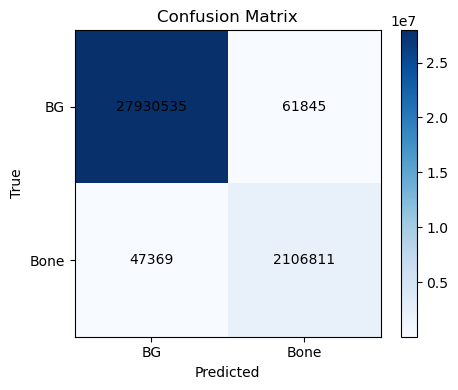

[Train] Epoch 6: 100%|██████████| 208/208 [09:14<00:00,  2.67s/it]



Epoch 6 - Train Loss: 0.0917
Epoch 6 - Val Loss: 0.0871 - Dice: 0.9696 - IoU: 0.9414
💾 Saved best model at epoch 6


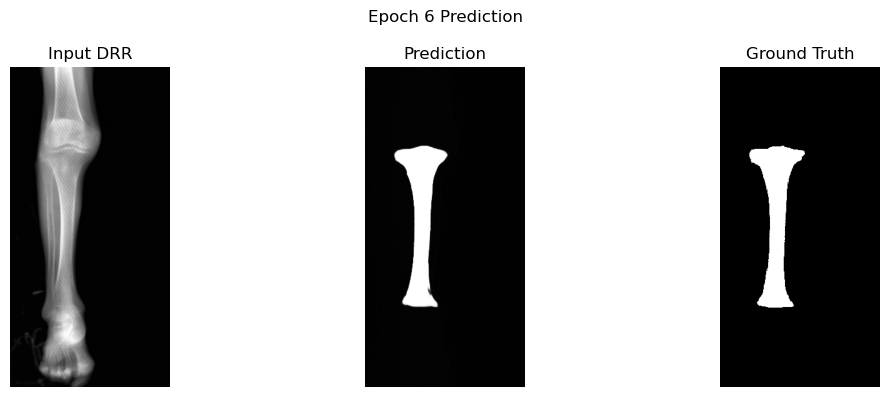

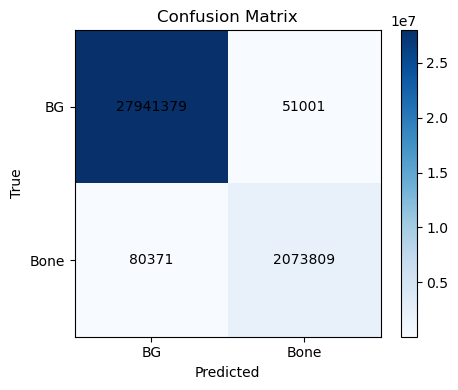

[Train] Epoch 7: 100%|██████████| 208/208 [09:15<00:00,  2.67s/it]



Epoch 7 - Train Loss: 0.0701
Epoch 7 - Val Loss: 0.0650 - Dice: 0.9761 - IoU: 0.9534
💾 Saved best model at epoch 7


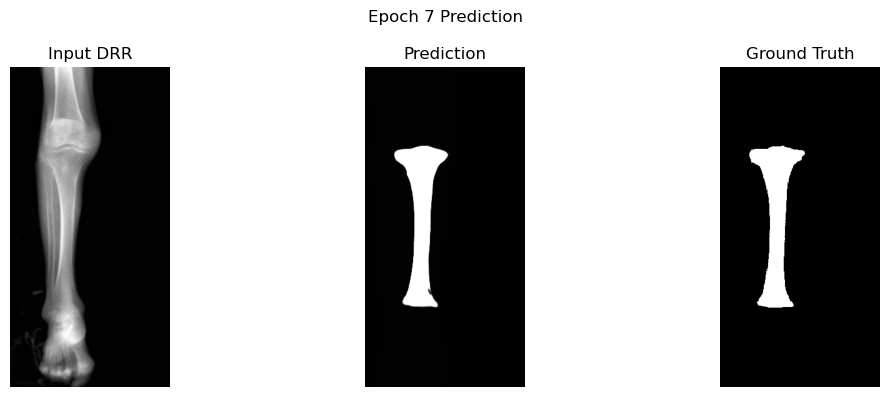

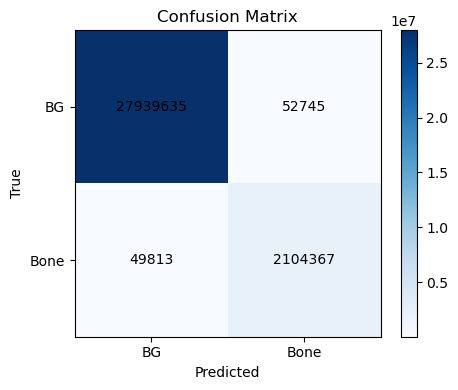

[Train] Epoch 8: 100%|██████████| 208/208 [09:14<00:00,  2.66s/it]



Epoch 8 - Train Loss: 0.0559
Epoch 8 - Val Loss: 0.0547 - Dice: 0.9753 - IoU: 0.9518
💾 Saved best model at epoch 8


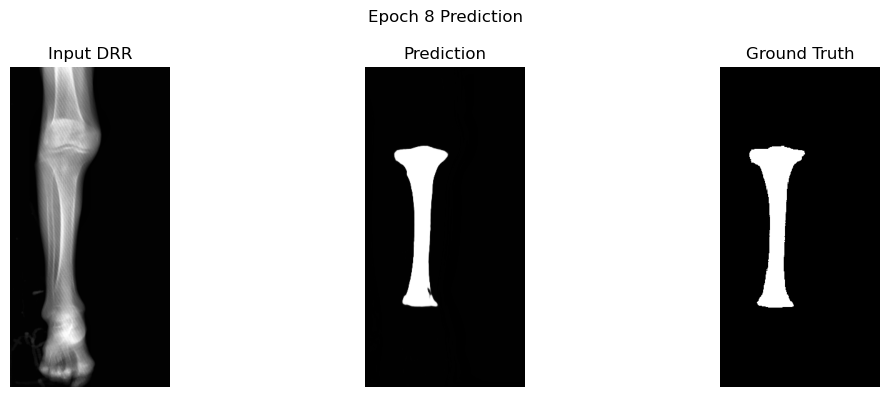

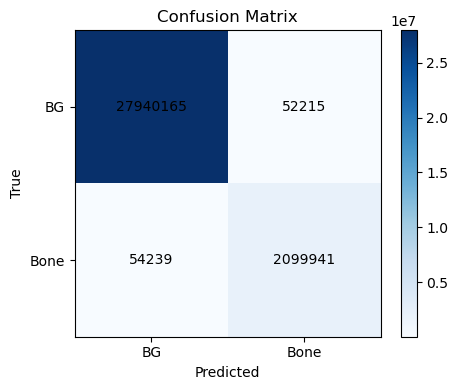

[Train] Epoch 9: 100%|██████████| 208/208 [09:13<00:00,  2.66s/it]



Epoch 9 - Train Loss: 0.0454
Epoch 9 - Val Loss: 0.0479 - Dice: 0.9752 - IoU: 0.9516
💾 Saved best model at epoch 9


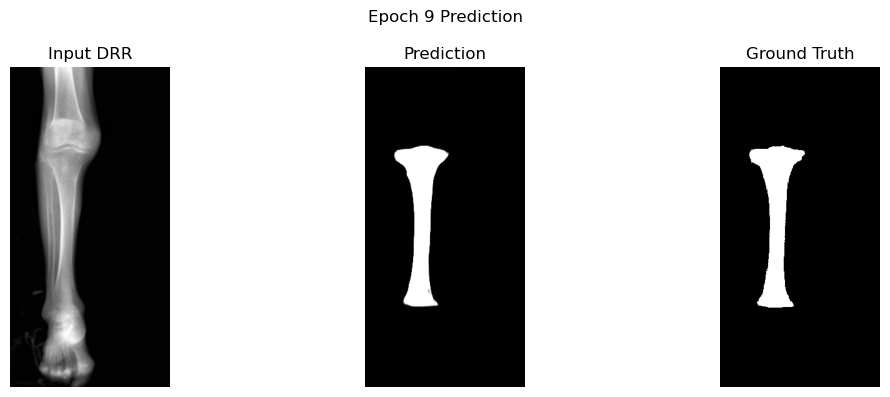

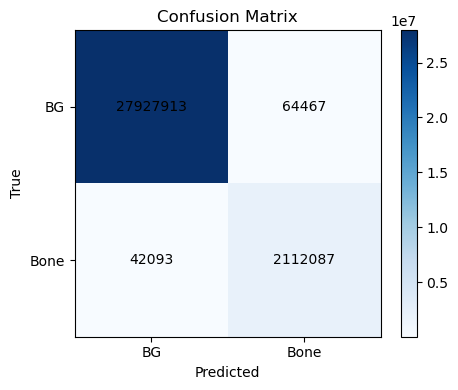

[Train] Epoch 10: 100%|██████████| 208/208 [09:16<00:00,  2.68s/it]



Epoch 10 - Train Loss: 0.0378
Epoch 10 - Val Loss: 0.0408 - Dice: 0.9744 - IoU: 0.9502
💾 Saved best model at epoch 10


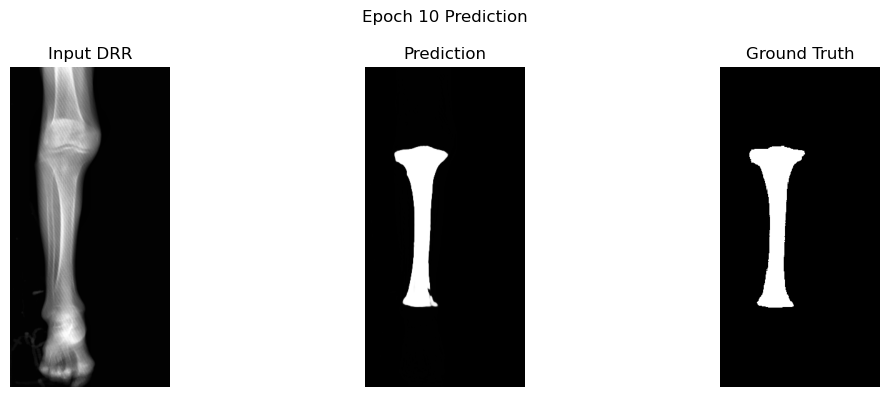

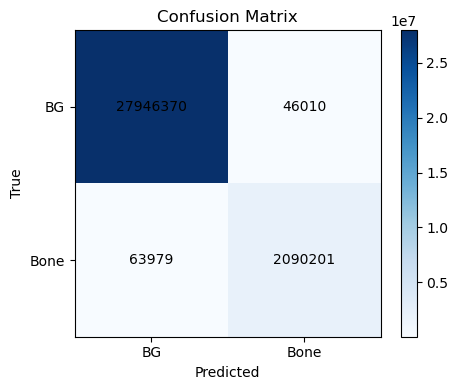

[Train] Epoch 11: 100%|██████████| 208/208 [09:15<00:00,  2.67s/it]



Epoch 11 - Train Loss: 0.0324
Epoch 11 - Val Loss: 0.0340 - Dice: 0.9766 - IoU: 0.9543
💾 Saved best model at epoch 11


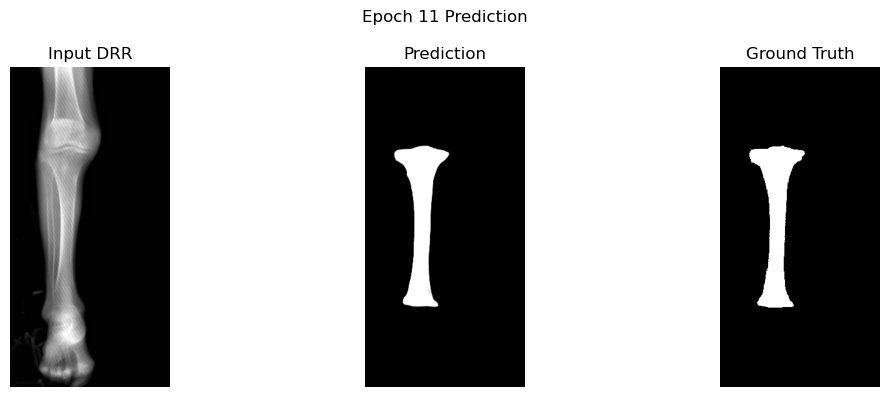

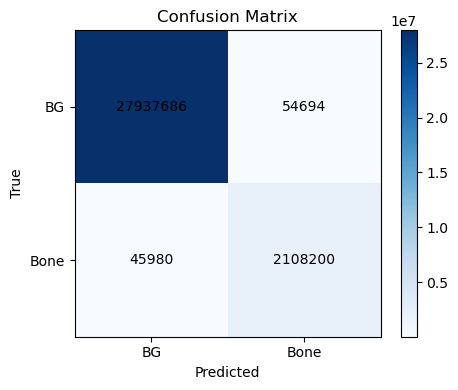

[Train] Epoch 12: 100%|██████████| 208/208 [09:17<00:00,  2.68s/it]



Epoch 12 - Train Loss: 0.0284
Epoch 12 - Val Loss: 0.0316 - Dice: 0.9770 - IoU: 0.9550
💾 Saved best model at epoch 12


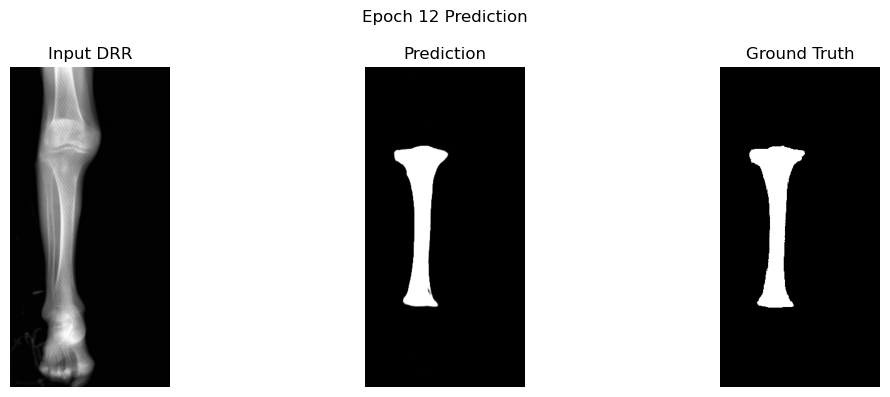

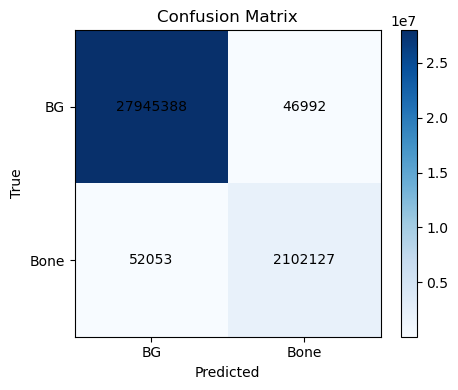

[Train] Epoch 13: 100%|██████████| 208/208 [09:14<00:00,  2.66s/it]



Epoch 13 - Train Loss: 0.0254
Epoch 13 - Val Loss: 0.2369 - Dice: 0.7782 - IoU: 0.6438


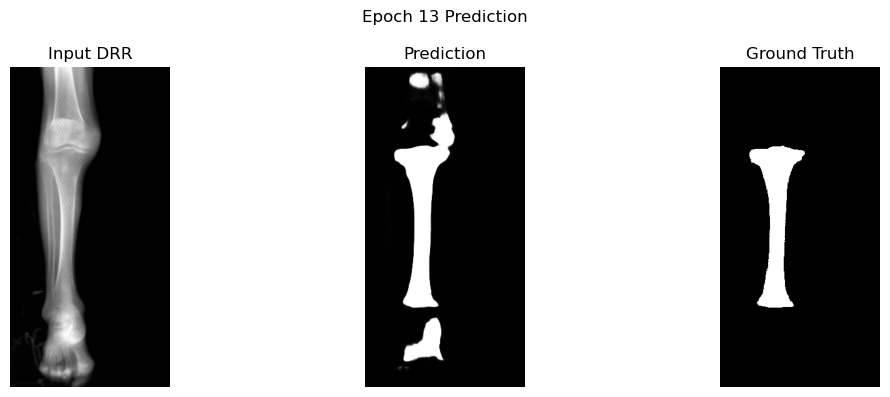

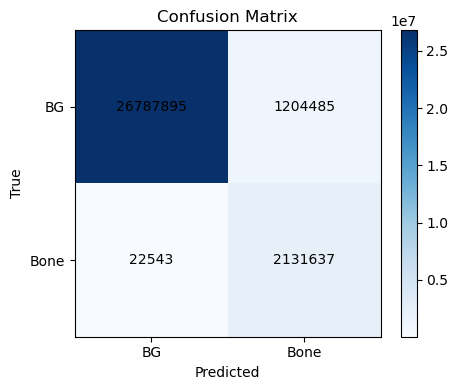

[Train] Epoch 14: 100%|██████████| 208/208 [09:16<00:00,  2.67s/it]



Epoch 14 - Train Loss: 0.0328
Epoch 14 - Val Loss: 0.0294 - Dice: 0.9747 - IoU: 0.9508
💾 Saved best model at epoch 14


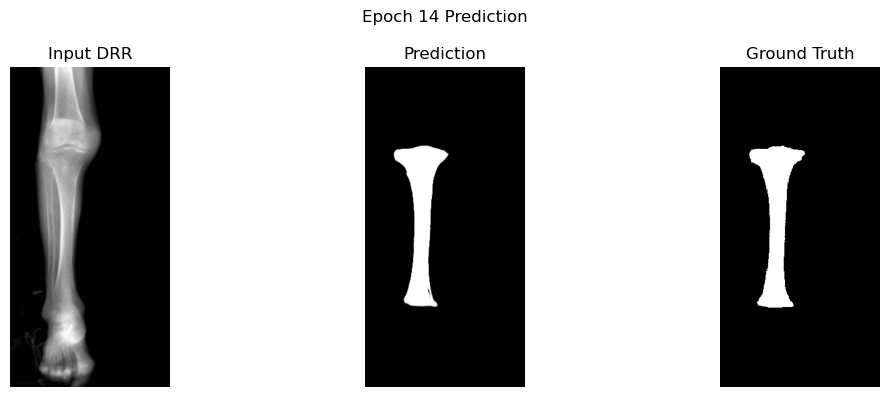

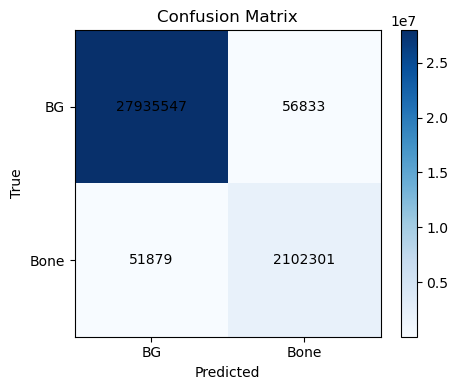

[Train] Epoch 15: 100%|██████████| 208/208 [09:15<00:00,  2.67s/it]



Epoch 15 - Train Loss: 0.0238
Epoch 15 - Val Loss: 0.0269 - Dice: 0.9754 - IoU: 0.9521
💾 Saved best model at epoch 15


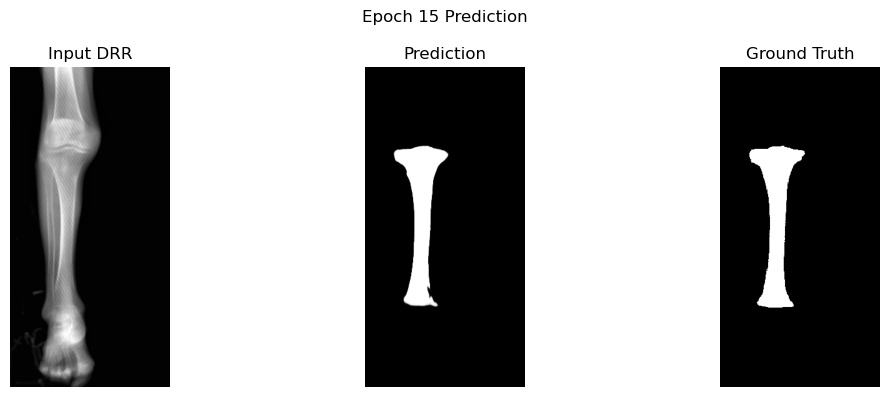

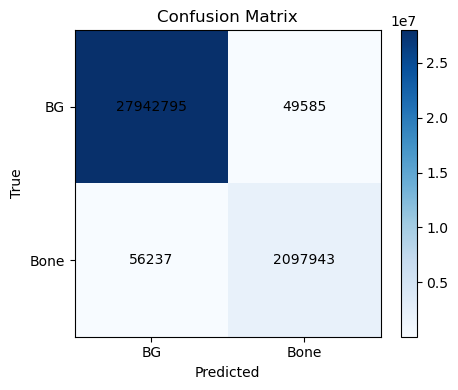

[Train] Epoch 16: 100%|██████████| 208/208 [09:13<00:00,  2.66s/it]



Epoch 16 - Train Loss: 0.0208
Epoch 16 - Val Loss: 0.0244 - Dice: 0.9765 - IoU: 0.9541
💾 Saved best model at epoch 16


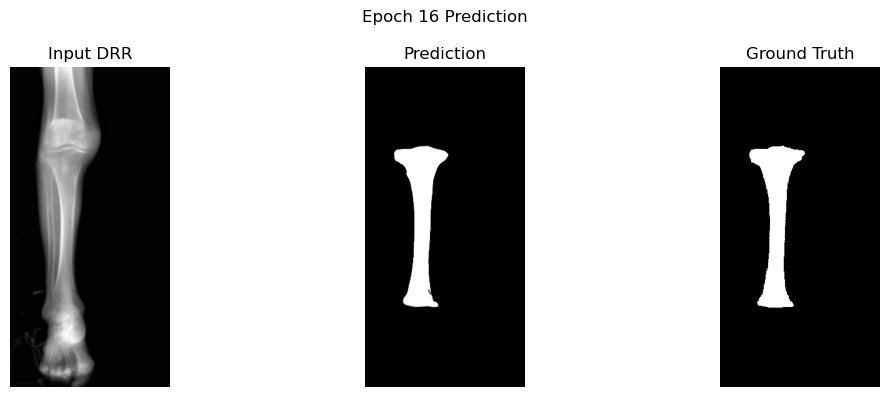

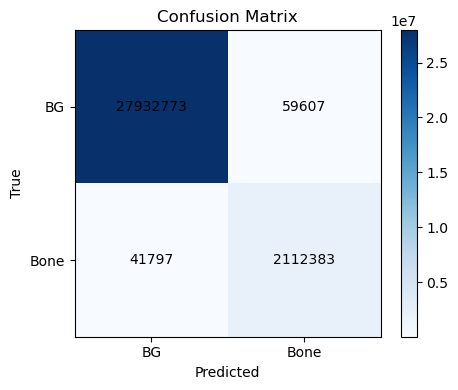

[Train] Epoch 17: 100%|██████████| 208/208 [09:14<00:00,  2.67s/it]



Epoch 17 - Train Loss: 0.0189
Epoch 17 - Val Loss: 0.0237 - Dice: 0.9765 - IoU: 0.9541
💾 Saved best model at epoch 17


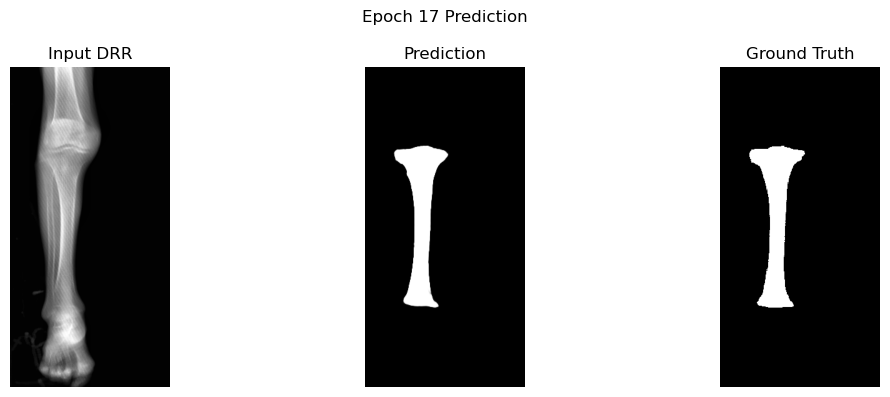

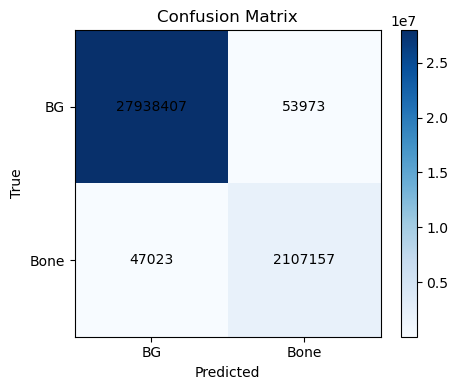

[Train] Epoch 18: 100%|██████████| 208/208 [09:21<00:00,  2.70s/it]



Epoch 18 - Train Loss: 0.0177
Epoch 18 - Val Loss: 0.0229 - Dice: 0.9770 - IoU: 0.9551
💾 Saved best model at epoch 18


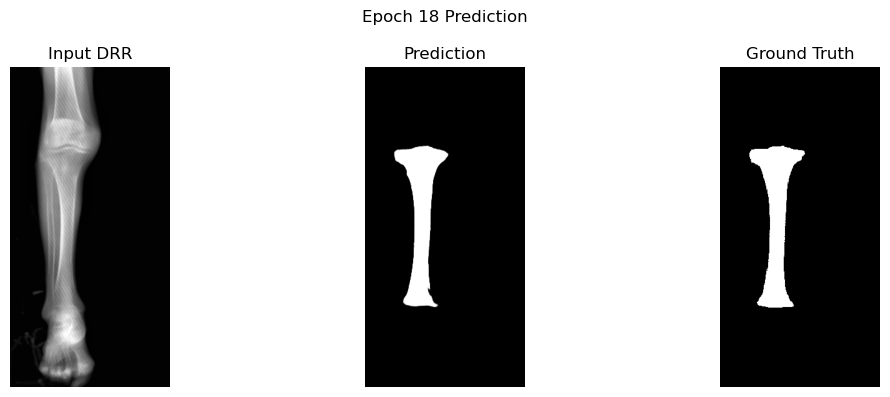

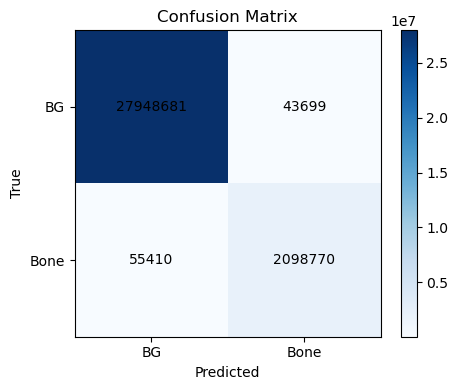

[Train] Epoch 19: 100%|██████████| 208/208 [09:14<00:00,  2.67s/it]



Epoch 19 - Train Loss: 0.0167
Epoch 19 - Val Loss: 0.0218 - Dice: 0.9772 - IoU: 0.9555
💾 Saved best model at epoch 19


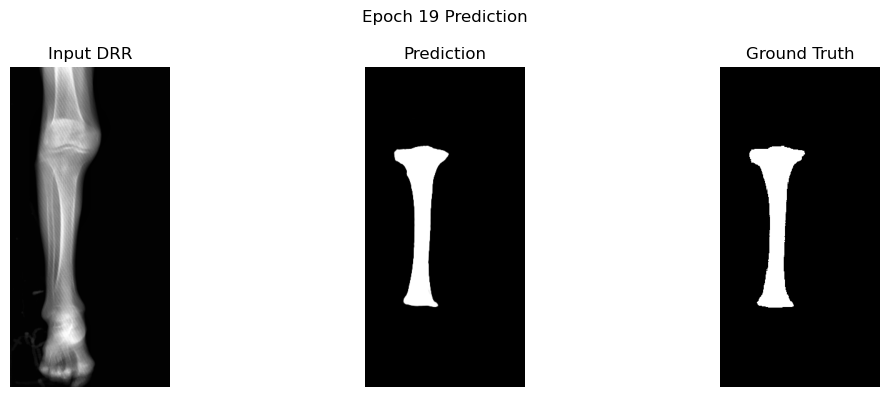

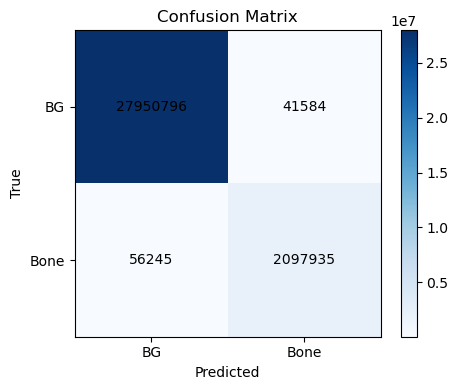

[Train] Epoch 20: 100%|██████████| 208/208 [09:15<00:00,  2.67s/it]



Epoch 20 - Train Loss: 0.0155
Epoch 20 - Val Loss: 0.0214 - Dice: 0.9774 - IoU: 0.9558
💾 Saved best model at epoch 20


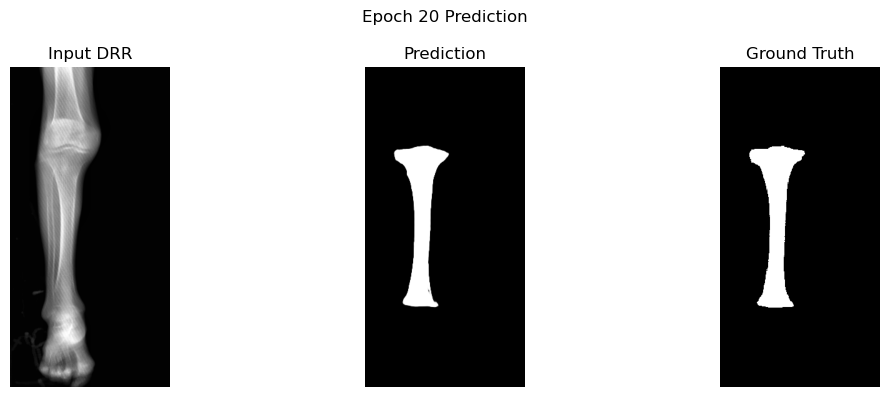

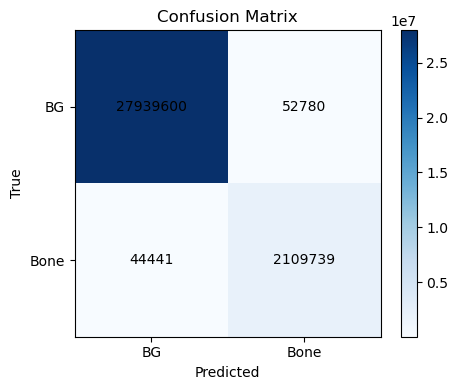

[Train] Epoch 21: 100%|██████████| 208/208 [09:16<00:00,  2.68s/it]



Epoch 21 - Train Loss: 0.0150
Epoch 21 - Val Loss: 0.0209 - Dice: 0.9772 - IoU: 0.9555
💾 Saved best model at epoch 21


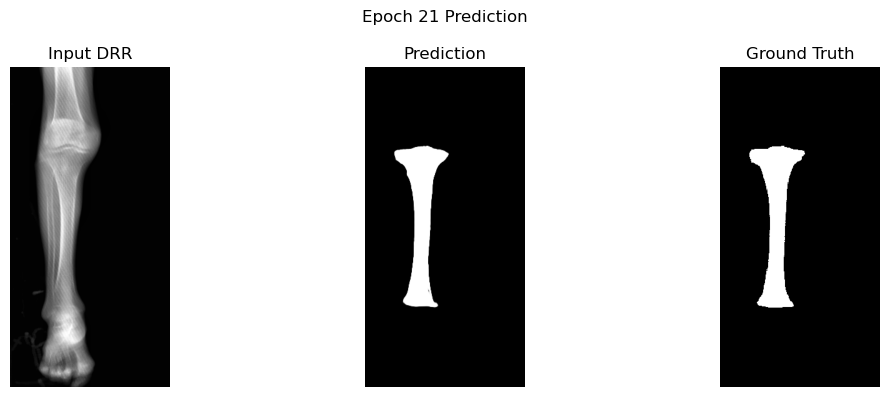

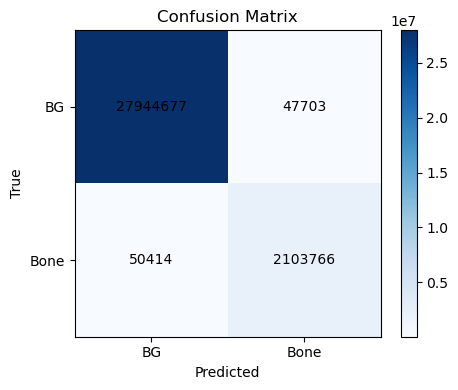

[Train] Epoch 22: 100%|██████████| 208/208 [09:16<00:00,  2.67s/it]



Epoch 22 - Train Loss: 0.0145
Epoch 22 - Val Loss: 0.0213 - Dice: 0.9763 - IoU: 0.9537


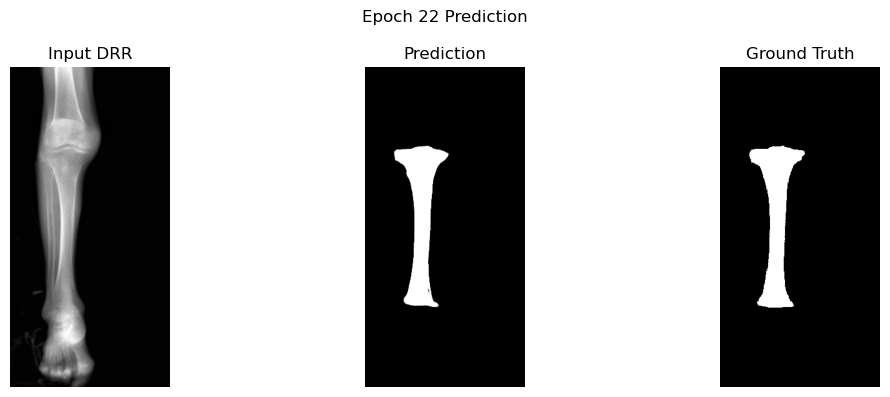

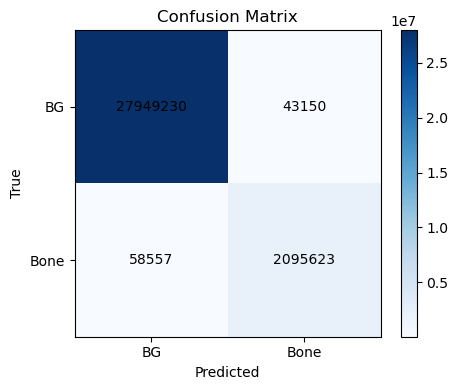

[Train] Epoch 23: 100%|██████████| 208/208 [09:19<00:00,  2.69s/it]



Epoch 23 - Train Loss: 0.0139
Epoch 23 - Val Loss: 0.0218 - Dice: 0.9750 - IoU: 0.9512


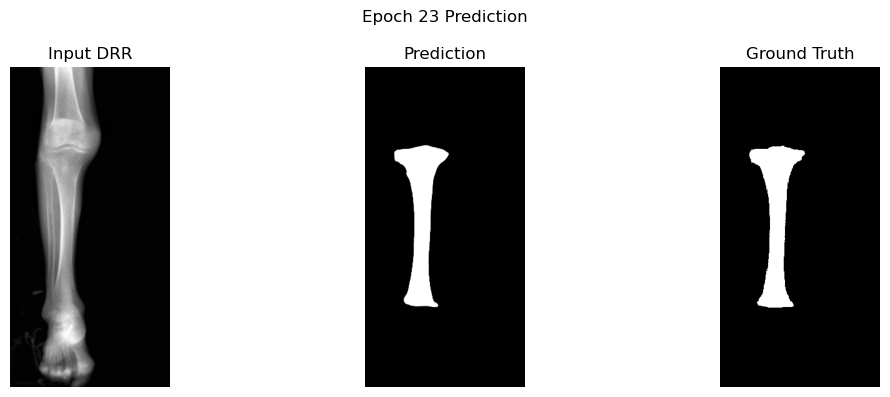

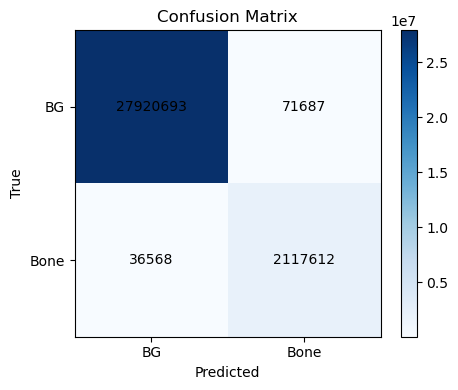

[Train] Epoch 24: 100%|██████████| 208/208 [09:18<00:00,  2.68s/it]



Epoch 24 - Train Loss: 0.0135
Epoch 24 - Val Loss: 0.0210 - Dice: 0.9761 - IoU: 0.9535


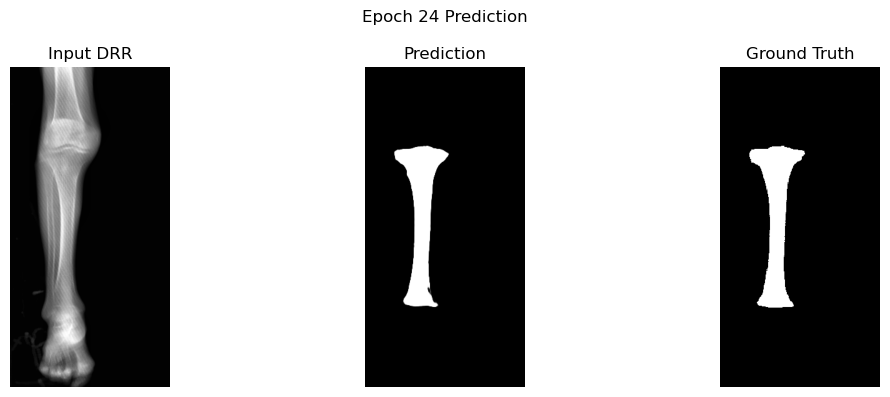

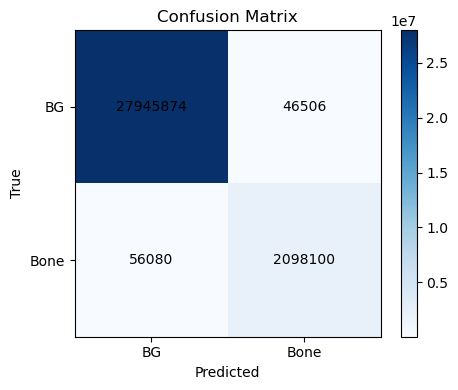

[Train] Epoch 25: 100%|██████████| 208/208 [09:18<00:00,  2.69s/it]



Epoch 25 - Train Loss: 0.0129
Epoch 25 - Val Loss: 0.0207 - Dice: 0.9761 - IoU: 0.9534
💾 Saved best model at epoch 25


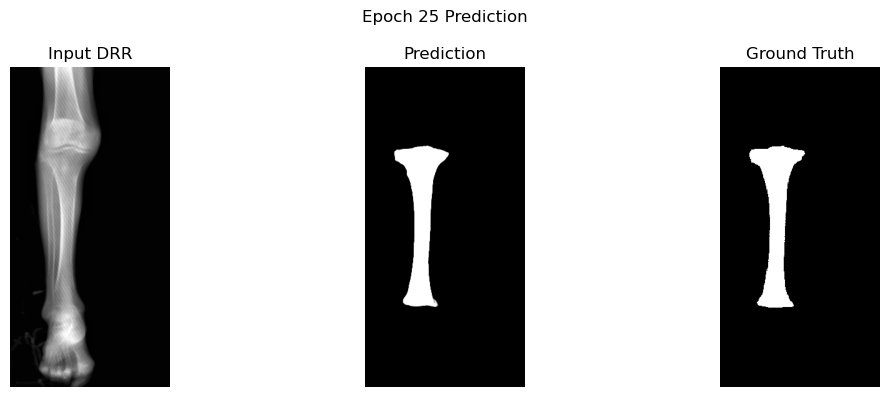

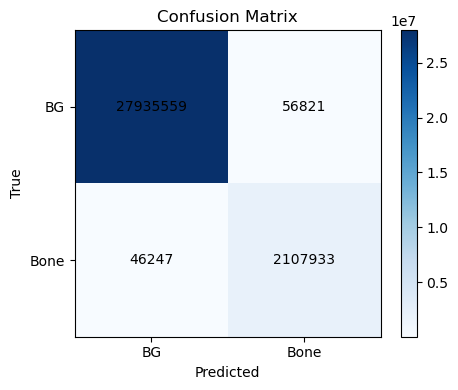

[Train] Epoch 26: 100%|██████████| 208/208 [09:24<00:00,  2.71s/it]



Epoch 26 - Train Loss: 0.0124
Epoch 26 - Val Loss: 0.0206 - Dice: 0.9762 - IoU: 0.9536
💾 Saved best model at epoch 26


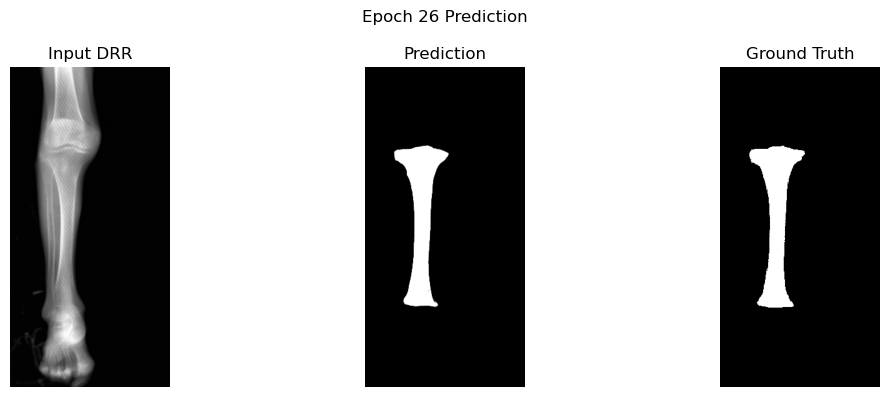

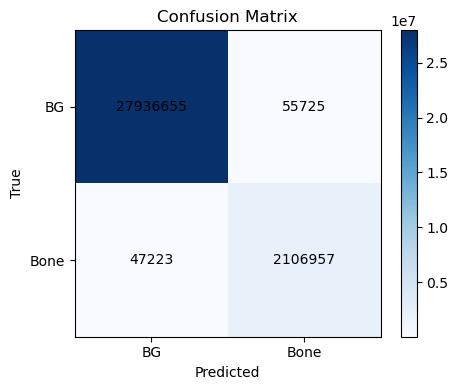

[Train] Epoch 27: 100%|██████████| 208/208 [09:19<00:00,  2.69s/it]



Epoch 27 - Train Loss: 0.0121
Epoch 27 - Val Loss: 0.0206 - Dice: 0.9760 - IoU: 0.9533


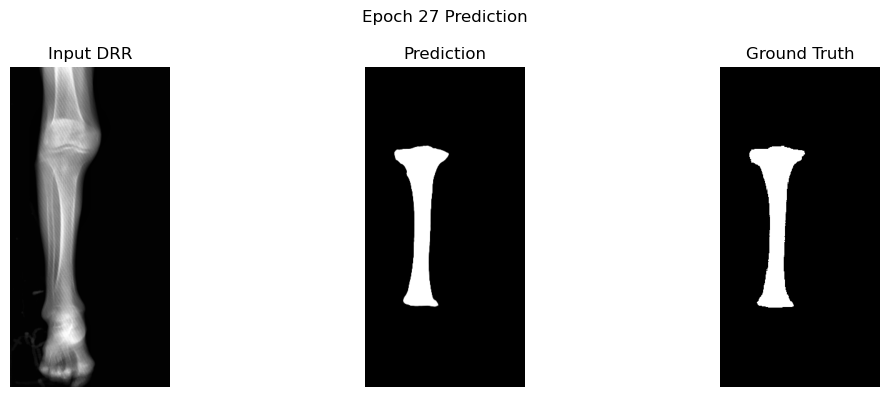

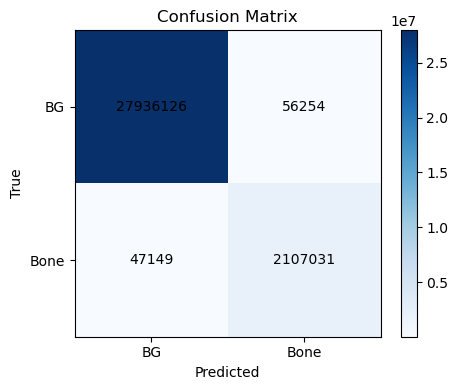

[Train] Epoch 28: 100%|██████████| 208/208 [09:16<00:00,  2.67s/it]



Epoch 28 - Train Loss: 0.0219
Epoch 28 - Val Loss: 0.0203 - Dice: 0.9753 - IoU: 0.9519
💾 Saved best model at epoch 28


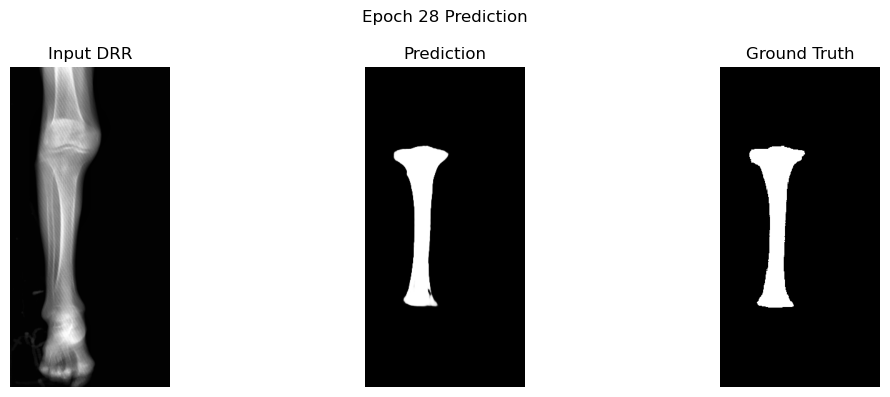

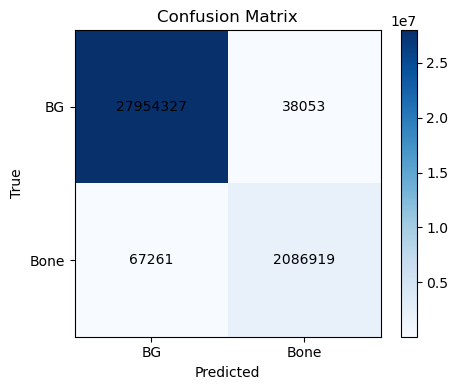

[Train] Epoch 29: 100%|██████████| 208/208 [09:16<00:00,  2.67s/it]



Epoch 29 - Train Loss: 0.0139
Epoch 29 - Val Loss: 0.0196 - Dice: 0.9764 - IoU: 0.9540
💾 Saved best model at epoch 29


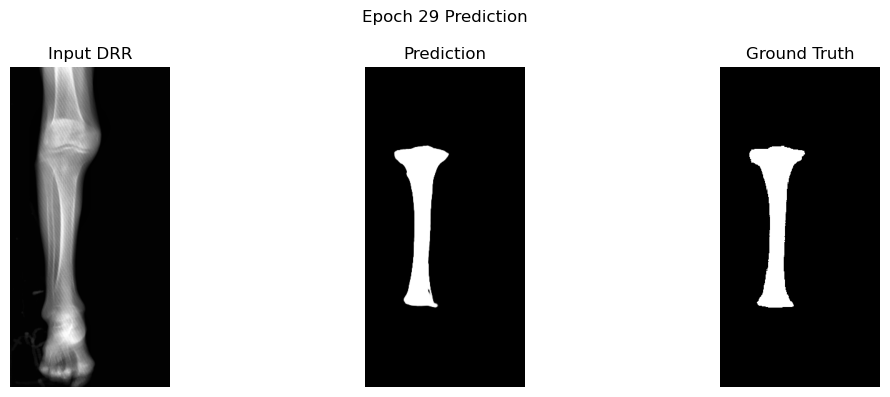

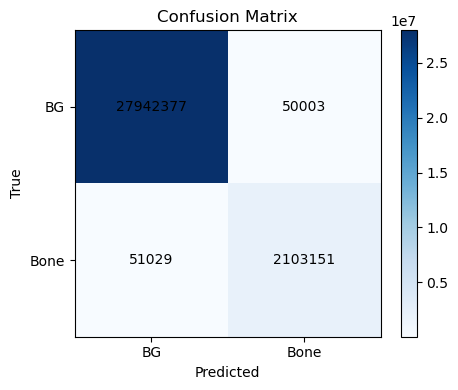

[Train] Epoch 30: 100%|██████████| 208/208 [09:16<00:00,  2.67s/it]



Epoch 30 - Train Loss: 0.0125
Epoch 30 - Val Loss: 0.0192 - Dice: 0.9768 - IoU: 0.9547
💾 Saved best model at epoch 30


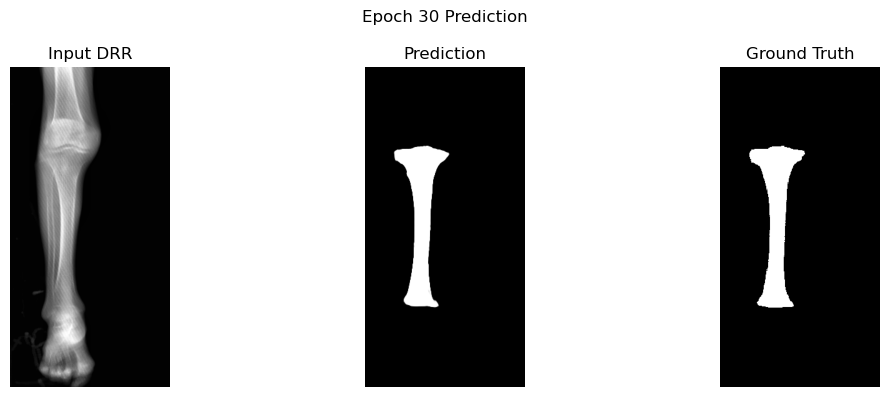

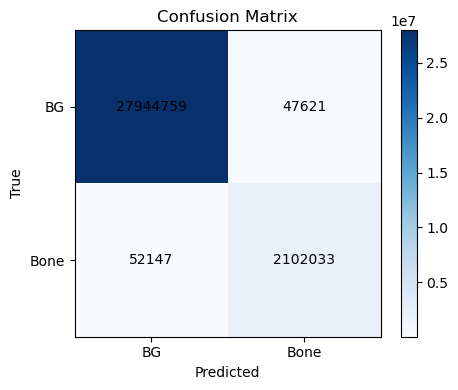

[Train] Epoch 31: 100%|██████████| 208/208 [09:15<00:00,  2.67s/it]



Epoch 31 - Train Loss: 0.0117
Epoch 31 - Val Loss: 0.0195 - Dice: 0.9767 - IoU: 0.9546


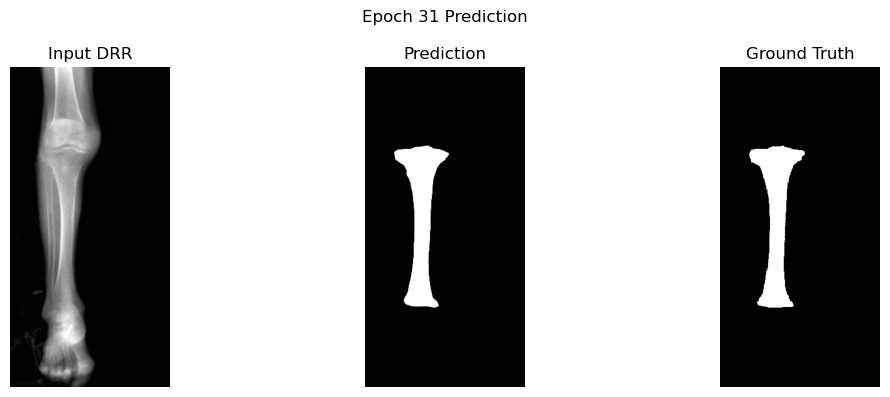

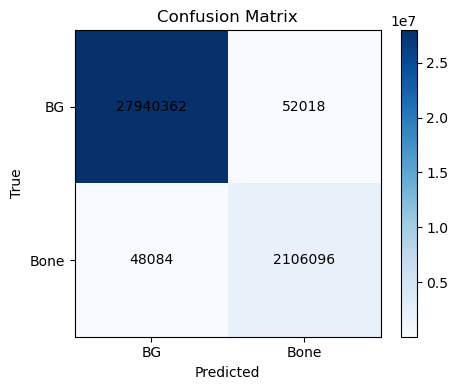

[Train] Epoch 32: 100%|██████████| 208/208 [09:15<00:00,  2.67s/it]



Epoch 32 - Train Loss: 0.0113
Epoch 32 - Val Loss: 0.0197 - Dice: 0.9767 - IoU: 0.9545


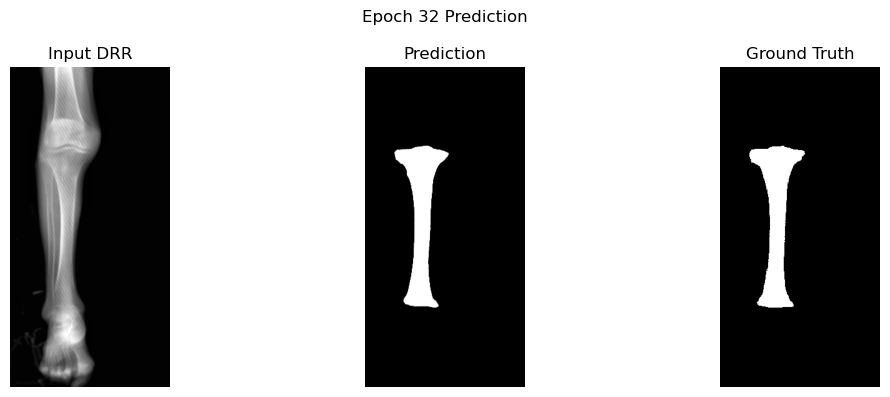

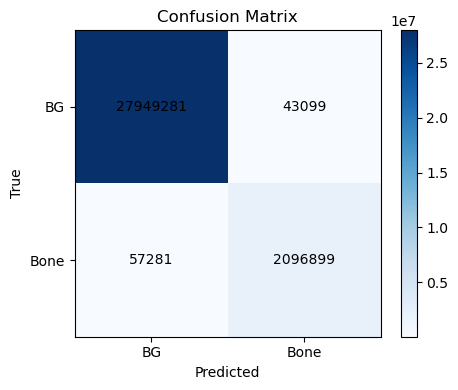

[Train] Epoch 33: 100%|██████████| 208/208 [09:17<00:00,  2.68s/it]



Epoch 33 - Train Loss: 0.0111
Epoch 33 - Val Loss: 0.0199 - Dice: 0.9763 - IoU: 0.9539


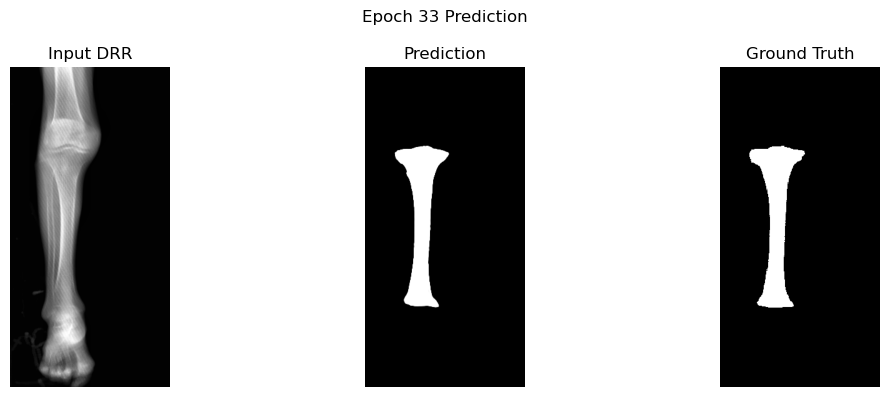

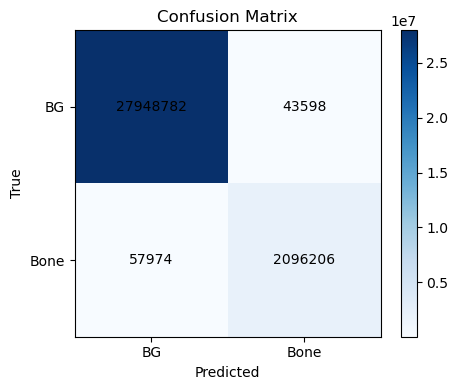

[Train] Epoch 34: 100%|██████████| 208/208 [09:16<00:00,  2.68s/it]



Epoch 34 - Train Loss: 0.0108
Epoch 34 - Val Loss: 0.0199 - Dice: 0.9761 - IoU: 0.9534


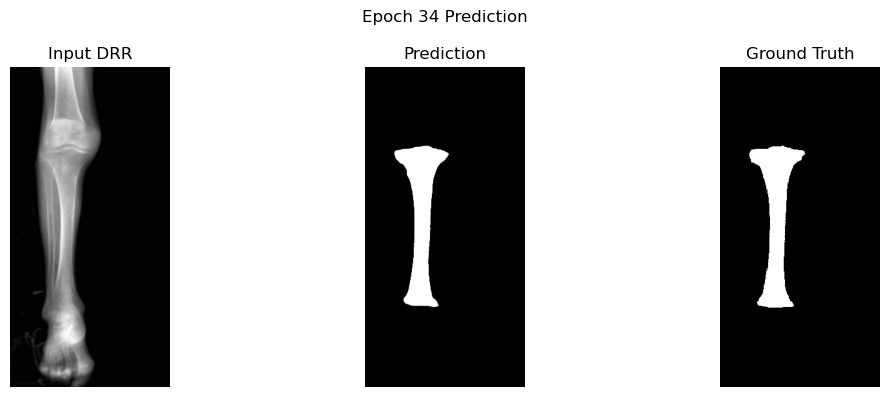

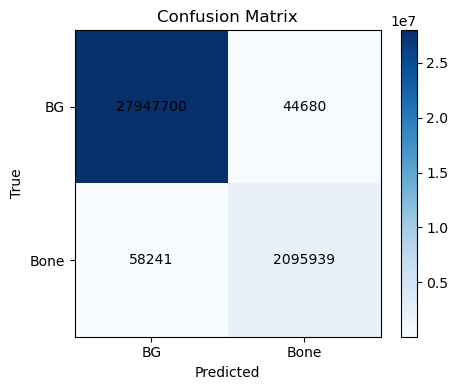

[Train] Epoch 35: 100%|██████████| 208/208 [09:22<00:00,  2.70s/it]



Epoch 35 - Train Loss: 0.0106
Epoch 35 - Val Loss: 0.0201 - Dice: 0.9762 - IoU: 0.9535
⛔ Early stopping triggered


In [5]:
model = AttentionUNet()
train(model, train_loader, val_loader, epochs=40, lr=1e-4)

In [6]:
##### Test Model

import torch
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from tqdm import tqdm
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_segmentation(test_data, checkpoint_path='AttentionUNet_V02_AP.pt'):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    test_set = NPYTibiaDataset(test_data, transform=ToTensorTransform())
    test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

    model = AttentionUNet().to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    dice_total, iou_total = 0, 0
    all_preds, all_masks = [], []

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="🔍 Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()

            dice_total += dice_score(preds, masks)
            iou_total += iou_score(preds, masks)

            all_preds.append(preds.cpu().numpy())
            all_masks.append(masks.cpu().numpy())

    avg_dice = dice_total / len(test_loader)
    avg_iou = iou_total / len(test_loader)

    all_preds = np.concatenate(all_preds).flatten()
    all_masks = np.concatenate(all_masks).flatten()

    precision = precision_score(all_masks, all_preds)
    recall = recall_score(all_masks, all_preds)
    f1 = f1_score(all_masks, all_preds)

    print(f"\n🧪 Final Evaluation Metrics:")
    print(f"Dice Coefficient: {avg_dice:.4f}")
    print(f"IoU: {avg_iou:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

evaluate_segmentation(test_data)


🔍 Evaluating: 100%|██████████| 140/140 [00:23<00:00,  5.92it/s]



🧪 Final Evaluation Metrics:
Dice Coefficient: 0.9793
IoU: 0.9595
Precision: 0.9803
Recall: 0.9782
F1 Score: 0.9792


##### Model Results
🧪 Final Evaluation Metrics:
- Dice Coefficient: 0.9793
- IoU: 0.9595
- Precision: 0.9803
- Recall: 0.9782
- F1 Score: 0.9792

Epoch 30 - Train Loss: 0.0125 - Val Loss: 0.0192 - Dice: 0.9768 - IoU: 0.9547

🔍 Testing: 100%|██████████| 140/140 [00:22<00:00,  6.18it/s]



🧪 Final Test Dice: 0.9793 | IoU: 0.9595


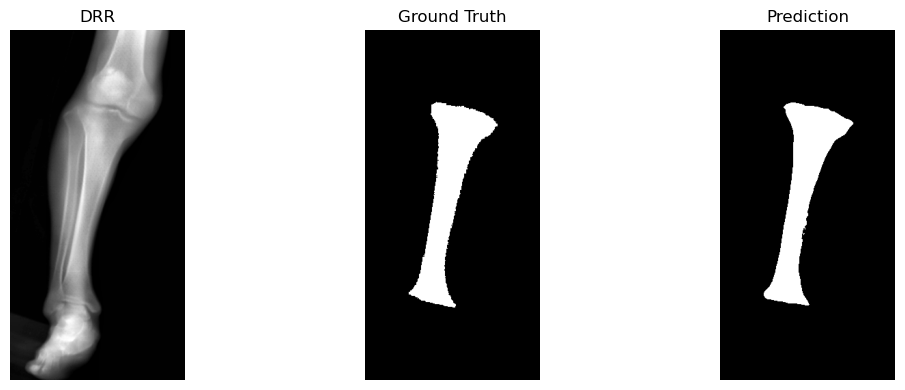

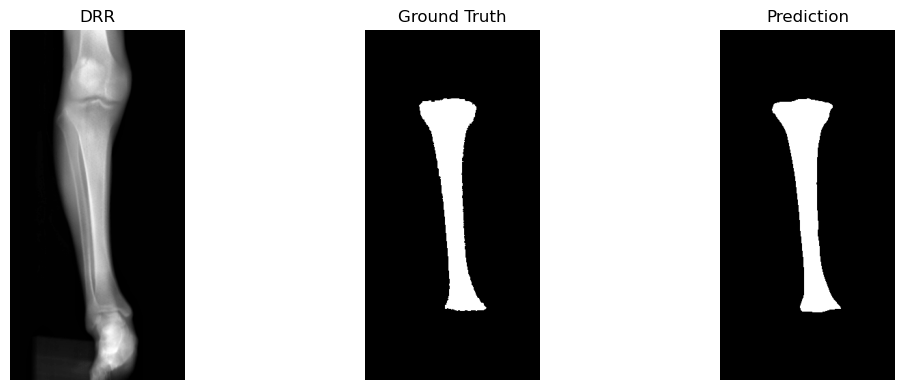

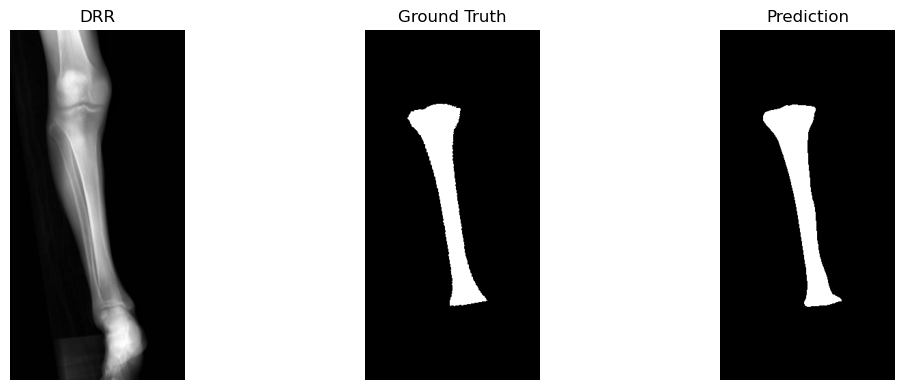

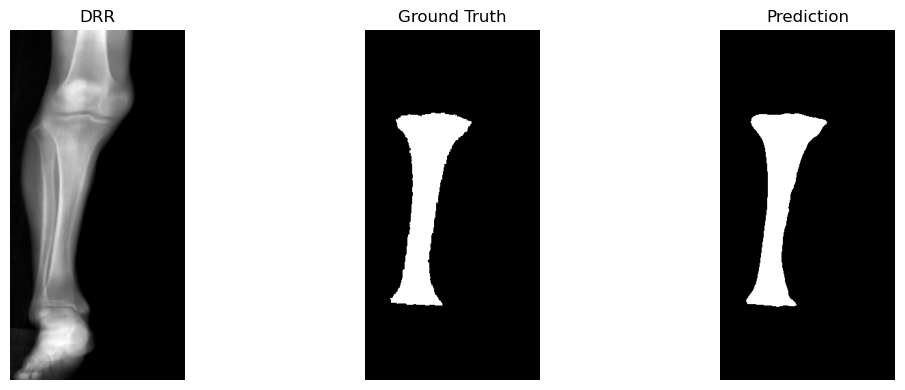

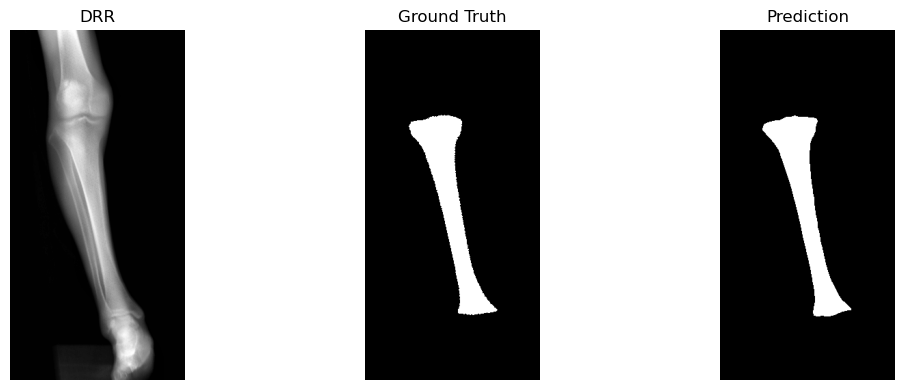

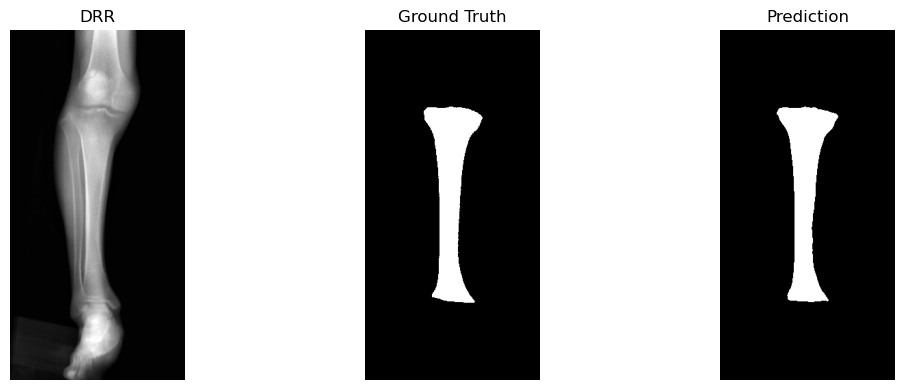

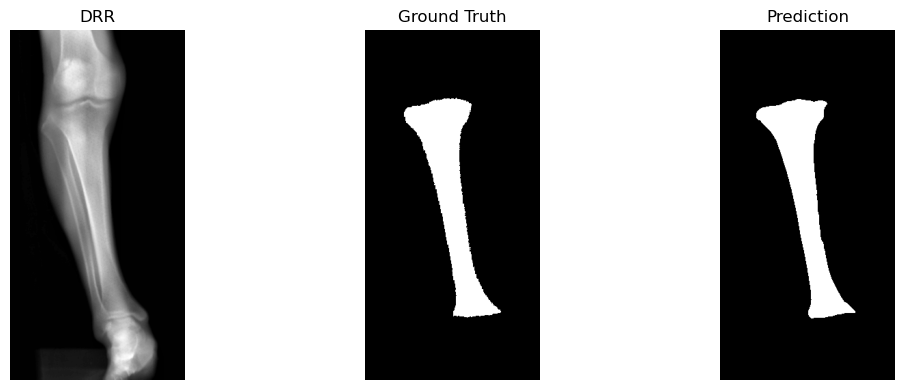

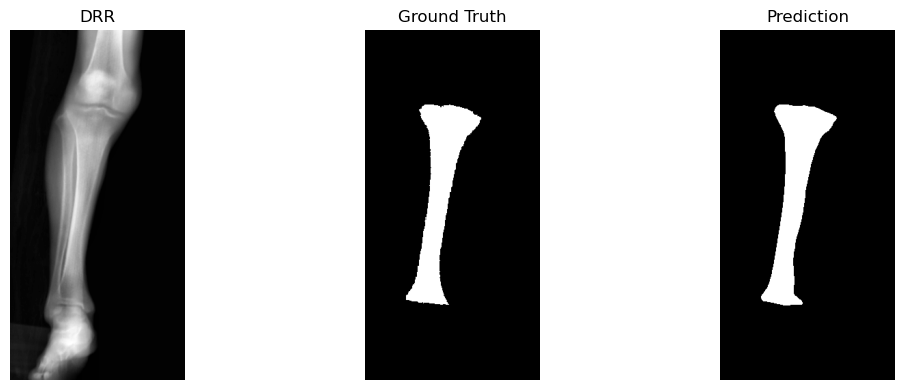

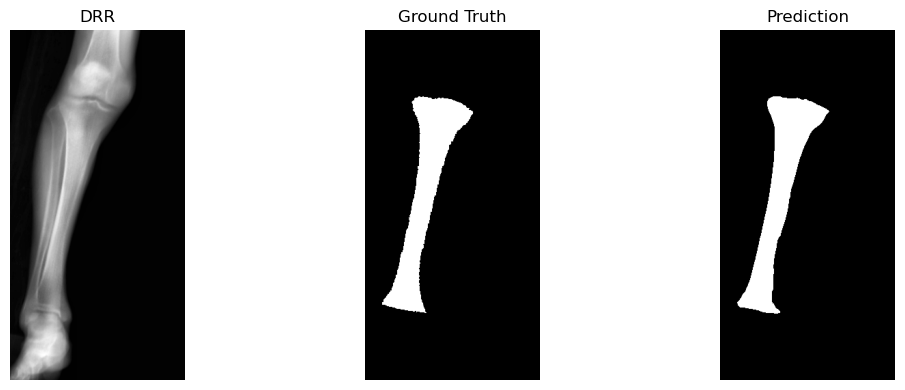

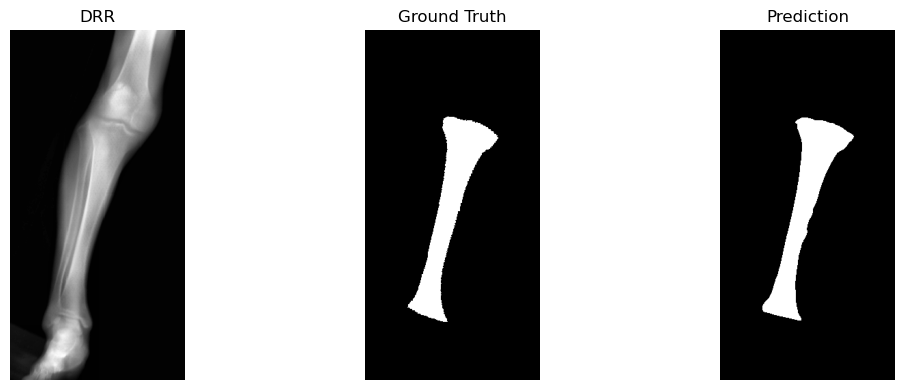

In [13]:
def show_predictions(images, masks, preds):
    for i in range(len(images)):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(images[i].squeeze().cpu(), cmap='gray')
        axs[0].set_title('DRR')
        axs[1].imshow(masks[i].squeeze().cpu(), cmap='gray')
        axs[1].set_title('Ground Truth')
        axs[2].imshow(preds[i].squeeze().cpu() > 0.5, cmap='gray')
        axs[2].set_title('Prediction')
        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

def test_model(test_data, checkpoint_path='AttentionUNet_V02_AP.pt', save_outputs=False, output_dir="test_outputs"):
    test_set = NPYTibiaDataset(test_data, transform=ToTensorTransform())
    test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

    model = AttentionUNet().to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    dice_total, iou_total = 0, 0
    all_images, all_masks, all_preds = [], [], []


    with torch.no_grad():
        for images , masks  in tqdm(test_loader, desc="🔍 Testing"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            preds = (outputs > 0.5).float()

            dice_total += dice_score(preds, masks)
            iou_total += iou_score(preds, masks)

            all_images.append(images[0])
            all_masks.append(masks[0])
            all_preds.append(preds[0])

    avg_dice = dice_total / len(test_loader)
    avg_iou = iou_total / len(test_loader)

    print(f"\n🧪 Final Test Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f}")

    # Show a few predictions
    show_predictions(all_images[:10], all_masks[:10], all_preds[:10])

# Example Usage (Set paths before running)
drr_dir= test_data[0][0]
mask_dir=test_data[0][1]
model = AttentionUNet()
test_model(test_data, checkpoint_path='AttentionUNet_V02_AP.pt')
